# Projeto Final M3 – Classificação de Imagens  
## Dataset D: DeepSat SAT-6

**Disciplina:** Processamento de Imagens  
**Curso:** Ciência da Computação  
**Tema:** Classificação automática de imagens de satélite usando CNN  
**Autores:** Gabrielly C. de Andrade e Nicolas F. Teixeira

---

## Objetivo do projeto

Desenvolver uma solução em Python para classificar automaticamente imagens do dataset **DeepSat SAT-6** em uma das seis classes de cobertura do solo:

1. Barren Land  
2. Trees  
3. Grassland  
4. Roads  
5. Buildings  
6. Water Bodies

# 1. Instalação e importação das bibliotecas

In [16]:
!pip install -q kaggle opencv-python scikit-learn matplotlib pillow

In [17]:
import os
import io
import random
import shutil
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Download do dataset DeepSat SAT-6 direto do Kaggle

In [18]:
DATASET_SLUG = "crawford/deepsat-sat6"
DATA_DIR = "/content/deepsat-sat6"

def configurar_kaggle():
    kaggle_dir = os.path.expanduser("~/.kaggle")
    kaggle_json_destino = os.path.join(kaggle_dir, "kaggle.json")

    if os.path.exists(kaggle_json_destino):
        print("Arquivo kaggle.json já configurado.")
        return

    os.makedirs(kaggle_dir, exist_ok=True)

    try:
        from google.colab import files
        print("Envie o arquivo kaggle.json baixado do site do Kaggle.")
        uploaded = files.upload()
        if "kaggle.json" not in uploaded:
            raise FileNotFoundError("Você precisa enviar o arquivo chamado kaggle.json.")
        with open(kaggle_json_destino, "wb") as f:
            f.write(uploaded["kaggle.json"])
        os.chmod(kaggle_json_destino, 0o600)
        print("kaggle.json configurado com sucesso.")
    except Exception as e:
        print("Não foi possível configurar automaticamente o kaggle.json.")
        print("Erro:", e)
        print("Coloque manualmente o arquivo em ~/.kaggle/kaggle.json.")

def baixar_dataset():
    os.makedirs(DATA_DIR, exist_ok=True)

    arquivos_esperados = [
        "X_train_sat6.csv",
        "y_train_sat6.csv",
        "X_test_sat6.csv",
        "y_test_sat6.csv"
    ]

    if all(os.path.exists(os.path.join(DATA_DIR, arq)) for arq in arquivos_esperados):
        print("Dataset já encontrado em:", DATA_DIR)
        return

    configurar_kaggle()
    print("Baixando dataset. Isso pode demorar alguns minutos...")
    comando = [
        "kaggle", "datasets", "download",
        "-d", DATASET_SLUG,
        "-p", DATA_DIR,
        "--unzip"
    ]
    subprocess.run(comando, check=True)
    print("Download finalizado.")

baixar_dataset()

print("\nArquivos encontrados:")
for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        print(os.path.join(root, file))

Dataset já encontrado em: /content/deepsat-sat6

Arquivos encontrados:
/content/deepsat-sat6/sat-6-full.mat
/content/deepsat-sat6/X_train_sat6.csv
/content/deepsat-sat6/y_test_sat6.csv
/content/deepsat-sat6/X_test_sat6.csv
/content/deepsat-sat6/sat6annotations.csv
/content/deepsat-sat6/y_train_sat6.csv


# 3. Carregamento dos dados



In [19]:
TRAIN_N = 32400   # use None para carregar todo o treino
TEST_N = 8100     # use None para carregar todo o teste

IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 4
NUM_CLASSES = 6

# Ordem de classes usada na descrição original do SAT-6.
CLASS_NAMES = [
    "Barren Land",
    "Trees",
    "Grassland",
    "Roads",
    "Buildings",
    "Water Bodies"
]

train_data_path = os.path.join(DATA_DIR, "X_train_sat6.csv")
train_label_path = os.path.join(DATA_DIR, "y_train_sat6.csv")
test_data_path = os.path.join(DATA_DIR, "X_test_sat6.csv")
test_label_path = os.path.join(DATA_DIR, "y_test_sat6.csv")

def carregar_csv_sat6(caminho_x, caminho_y, nrows=None):
    print(f"Lendo {os.path.basename(caminho_x)}...")
    X_df = pd.read_csv(caminho_x, header=None, dtype=np.uint8, nrows=nrows)

    print(f"Lendo {os.path.basename(caminho_y)}...")
    y_df = pd.read_csv(caminho_y, header=None, dtype=np.uint8, nrows=nrows)

    X = X_df.to_numpy().reshape(-1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
    y = y_df.to_numpy().astype("float32")

    del X_df, y_df
    return X, y

X_train_raw, y_train_onehot = carregar_csv_sat6(train_data_path, train_label_path, TRAIN_N)
X_test_raw, y_test_onehot = carregar_csv_sat6(test_data_path, test_label_path, TEST_N)

print("X_train_raw:", X_train_raw.shape, X_train_raw.dtype)
print("y_train_onehot:", y_train_onehot.shape, y_train_onehot.dtype)
print("X_test_raw:", X_test_raw.shape, X_test_raw.dtype)
print("y_test_onehot:", y_test_onehot.shape, y_test_onehot.dtype)

y_train_idx = np.argmax(y_train_onehot, axis=1)
y_test_idx = np.argmax(y_test_onehot, axis=1)

Lendo X_train_sat6.csv...
Lendo y_train_sat6.csv...
Lendo X_test_sat6.csv...
Lendo y_test_sat6.csv...
X_train_raw: (32400, 28, 28, 4) uint8
y_train_onehot: (32400, 6) float32
X_test_raw: (8100, 28, 28, 4) uint8
y_test_onehot: (8100, 6) float32


# 4. Visualização inicial das imagens

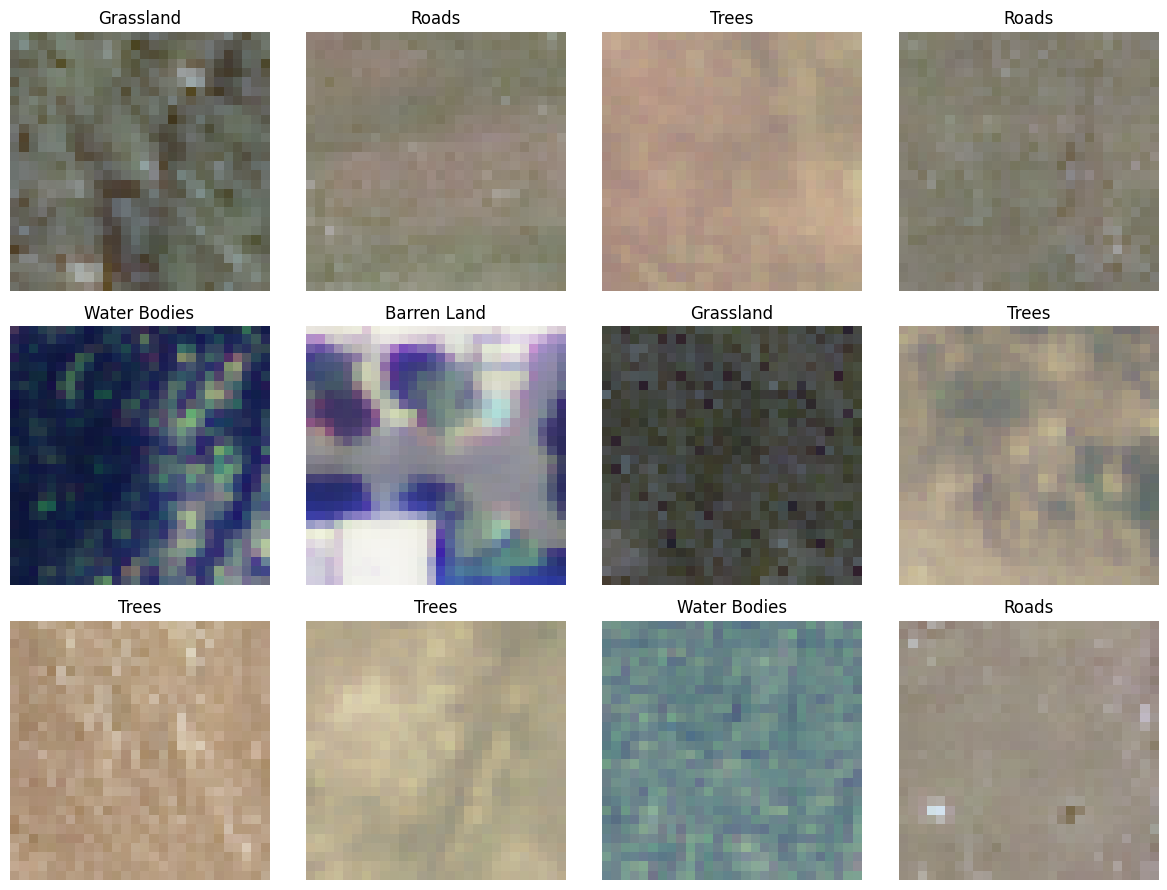

In [20]:
def mostrar_amostras(X, y_idx, class_names, n=12):
    indices = np.random.choice(len(X), size=n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(12, 3 * rows))

    for i, idx in enumerate(indices):
        img_rgb = X[idx, :, :, :3]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        plt.title(class_names[y_idx[idx]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_amostras(X_train_raw, y_train_idx, CLASS_NAMES, n=12)

# 5. Pré-processamento das imagens

Técnicas aplicadas:

1. **Equalização adaptativa de histograma com CLAHE nos canais RGB**  
   Ajuda a melhorar contraste local e reduzir problemas de variação de iluminação.

2. **Normalização para o intervalo [0, 1]**  
   Facilita o treinamento da rede neural.

3. **Preservação do canal NIR**  
   O quarto canal contém informação multiespectral útil para diferenciar classes visualmente parecidas.

4. **Data augmentation durante o treinamento**  
   Aumenta a capacidade de generalização do modelo com rotações, espelhamentos e pequenos zooms.

In [34]:
APPLY_CLAHE = True

def aplicar_clahe_rgb(batch_uint8):
    """
    Aplica CLAHE somente nos três canais RGB.
    O canal NIR é preservado sem equalização.
    """
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    saida = np.empty_like(batch_uint8)

    for i in range(batch_uint8.shape[0]):
        img = batch_uint8[i]
        for c in range(3):
            saida[i, :, :, c] = clahe.apply(img[:, :, c])
        saida[i, :, :, 3] = img[:, :, 3]

    return saida

def preprocessar_imagens(batch_uint8, aplicar_clahe=True):
    if aplicar_clahe:
        batch_uint8 = aplicar_clahe_rgb(batch_uint8)
    batch_float = batch_uint8.astype("float32") / 255.0
    return batch_float

X_train_pp = preprocessar_imagens(X_train_raw, aplicar_clahe=APPLY_CLAHE)
X_test_pp = preprocessar_imagens(X_test_raw, aplicar_clahe=APPLY_CLAHE)

print("Shape:", X_train_pp.shape)

Shape: (32400, 28, 28, 4)


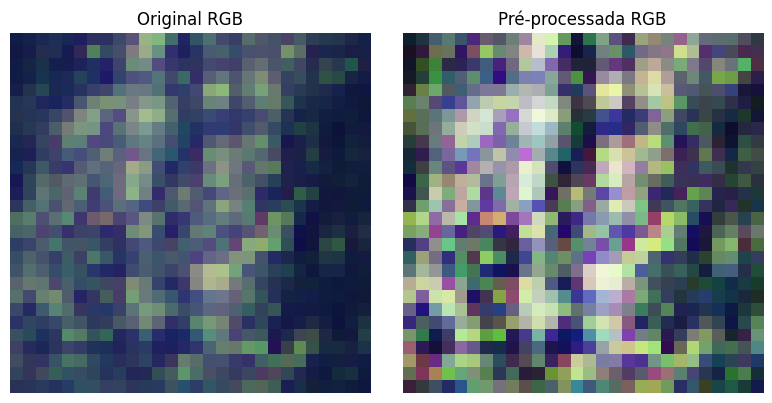

In [22]:
# Comparação visual antes e depois do pré-processamento
idx = np.random.randint(0, len(X_train_raw))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X_train_raw[idx, :, :, :3])
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(X_train_pp[idx, :, :, :3])
plt.title("Pré-processada RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

# 6. Separação entre treino e validação

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pp,
    y_train_onehot,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_idx
)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test_pp.shape, y_test_onehot.shape)

Treino: (25920, 28, 28, 4) (25920, 6)
Validação: (6480, 28, 28, 4) (6480, 6)
Teste: (8100, 28, 28, 4) (8100, 6)


# 7. Desenvolvimento do algoritmo de classificação

## Fluxo do método

1. Entrada: imagem 28x28x4;
2. Data augmentation;
3. Blocos convolucionais com Conv2D, BatchNormalization, MaxPooling2D e Dropout;
4. GlobalAveragePooling2D;
5. Camada densa;
6. Saída Softmax com 6 classes.

In [24]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal_and_vertical", seed=SEED),
        layers.RandomRotation(0.10, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
    ],
    name="data_augmentation"
)

def criar_modelo_cnn():
    inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), name="imagem_sat6")

    x = data_augmentation(inputs)

    x = layers.Conv2D(32, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="classe")(x)

    model = keras.Model(inputs, outputs, name="CNN_DeepSat_SAT6")
    return model

model = criar_modelo_cnn()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "CNN_DeepSat_SAT6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagem_sat6 (InputLayer)        │ (None, 28, 28, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classe (Dense)                  │ (None, 6)              │           77

 Total params: 305,254 (1.16 MB)

 Trainable params: 304,806 (1.16 MB)

 Non-trainable params: 448 (1.75 KB)

# 8. Treinamento

O treinamento usa:

- `EarlyStopping` para parar quando a validação não melhora;
- `ReduceLROnPlateau` para reduzir a taxa de aprendizado quando necessário.

In [25]:
BATCH_SIZE = 128
EPOCHS = 25

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8967 - loss: 0.2752 - val_accuracy: 0.1809 - val_loss: 3.7623 - learning_rate: 0.0010
Epoch 2/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9545 - loss: 0.1331 - val_accuracy: 0.3440 - val_loss: 3.1341 - learning_rate: 0.0010
Epoch 3/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9638 - loss: 0.1037 - val_accuracy: 0.7568 - val_loss: 2.2381 - learning_rate: 0.0010
Epoch 4/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9693 - loss: 0.0869 - val_accuracy: 0.9539 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 5/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9690 - loss: 0.0851 - val_accuracy: 0.6628 - val_loss: 2.2516 - learning_rate: 0.0010
Epoch 6/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9719 - loss: 0.0829 - val_accuracy: 0.9415 - val_loss: 0.1960 - learning_rate: 0.0010
Epoch 7/25
203/203 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9765 - loss: 0.

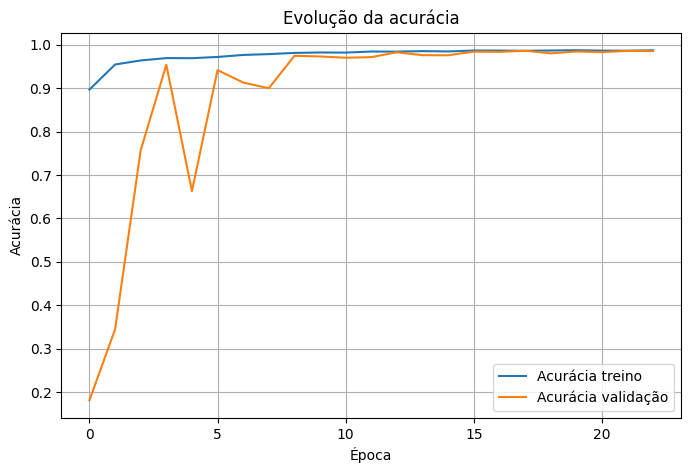

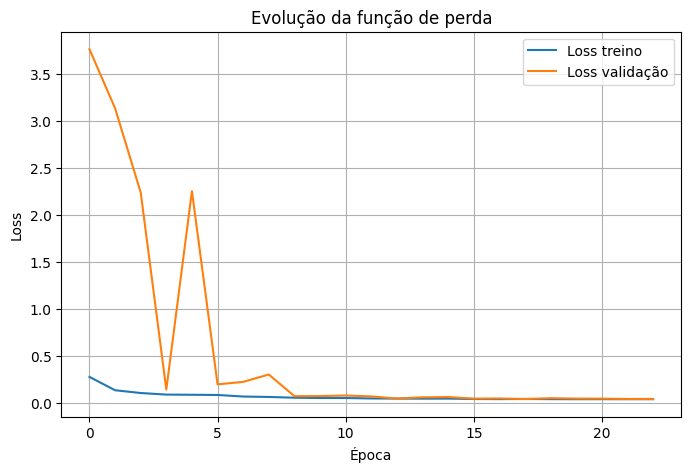

In [26]:
def plotar_historico(history):
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Acurácia treino")
    plt.plot(hist["val_accuracy"], label="Acurácia validação")
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.title("Evolução da acurácia")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Loss treino")
    plt.plot(hist["val_loss"], label="Loss validação")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title("Evolução da função de perda")
    plt.legend()
    plt.grid(True)
    plt.show()

plotar_historico(history)

# 9. Avaliação do modelo no conjunto de teste

Nesta etapa são calculadas as métricas obrigatórias:

- Acurácia;
- Precisão;
- Recall;
- F1-score;
- Matriz de confusão.

In [27]:
test_loss, test_acc = model.evaluate(X_test_pp, y_test_onehot, batch_size=BATCH_SIZE, verbose=0)

y_prob = model.predict(X_test_pp, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

acc = accuracy_score(y_true, y_pred)

print(f"Loss de teste: {test_loss:.4f}")
print(f"Acurácia de teste pelo Keras: {test_acc:.4f}")
print(f"Acurácia de teste pelo sklearn: {acc:.4f}")
print("\nRelatório de classificação:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Loss de teste: 0.0381
Acurácia de teste pelo Keras: 0.9868
Acurácia de teste pelo sklearn: 0.9868

Relatório de classificação:
              precision    recall  f1-score   support

 Barren Land     0.9892    0.9892    0.9892       370
       Trees     0.9945    0.9692    0.9817      1850
   Grassland     0.9859    0.9932    0.9896      1478
       Roads     0.9502    0.9768    0.9633      1251
   Buildings     0.9801    0.9657    0.9728       204
Water Bodies     0.9986    1.0000    0.9993      2947

    accuracy                         0.9868      8100
   macro avg     0.9831    0.9824    0.9827      8100
weighted avg     0.9870    0.9868    0.9868      8100



<Figure size 900x800 with 0 Axes>

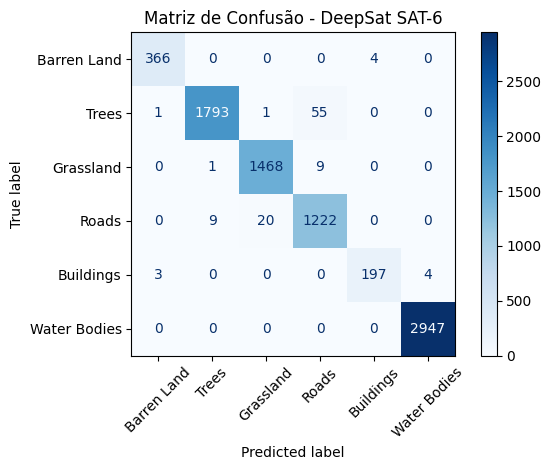

In [28]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Matriz de Confusão - DeepSat SAT-6")
plt.tight_layout()
plt.show()

# 10. Exemplos de inferência no conjunto de teste

A célula abaixo mostra imagens do conjunto de teste com:

- Classe real;
- Classe prevista;
- Probabilidade da previsão.

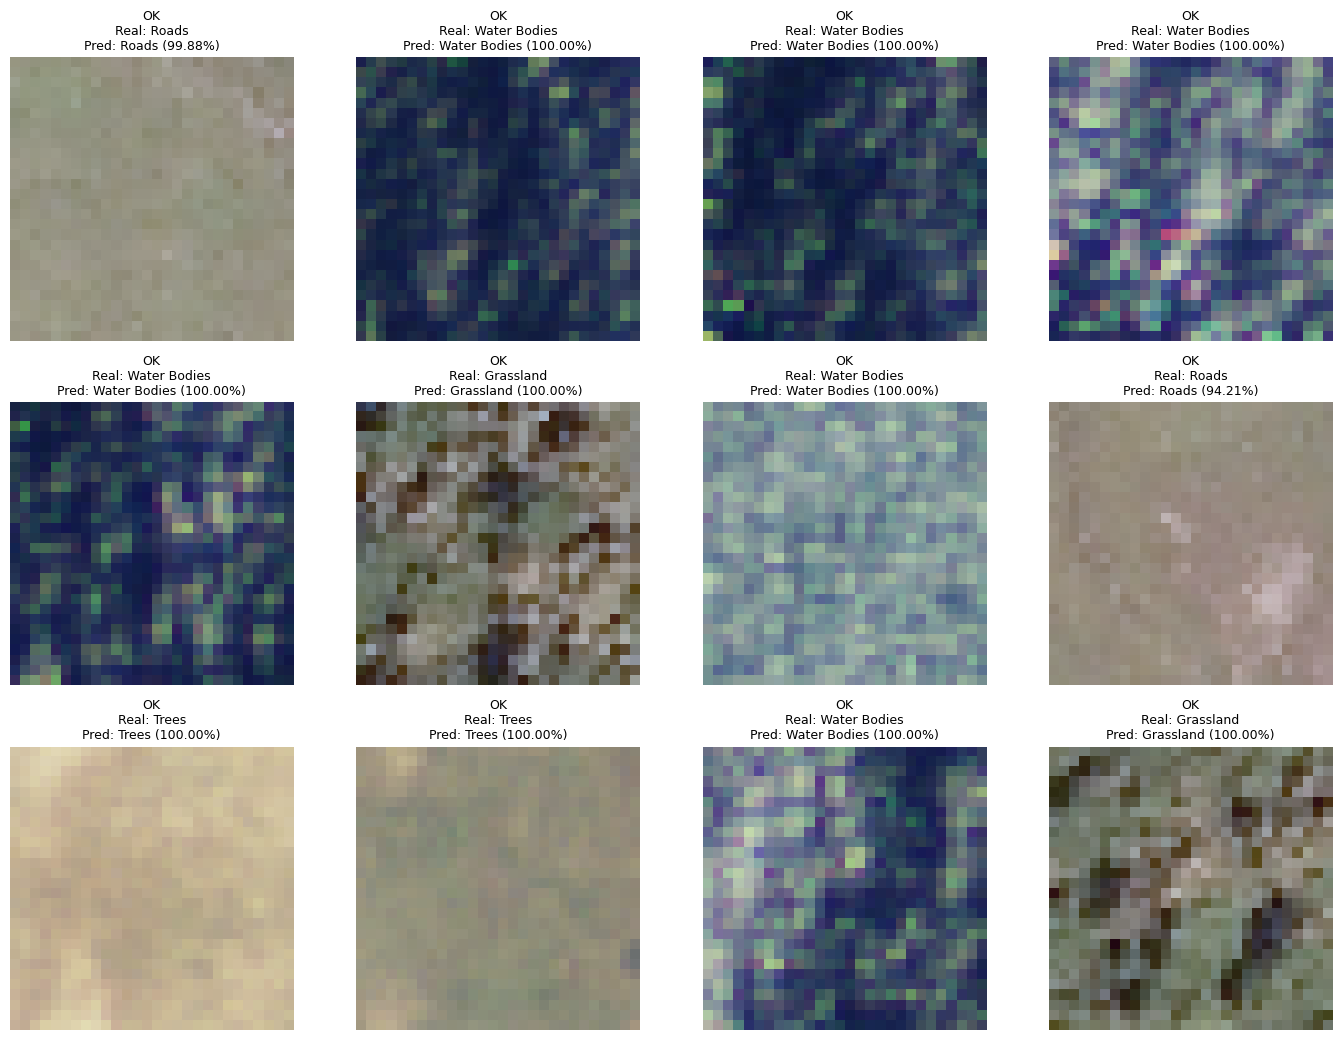

In [29]:
def mostrar_predicoes(model, X_raw, X_preprocessado, y_true_idx, class_names, n=12):
    indices = np.random.choice(len(X_preprocessado), size=n, replace=False)
    probs = model.predict(X_preprocessado[indices], verbose=0)
    preds = np.argmax(probs, axis=1)

    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(14, 3.5 * rows))

    for i, idx in enumerate(indices):
        real = class_names[y_true_idx[idx]]
        pred = class_names[preds[i]]
        conf = probs[i, preds[i]]
        correto = "OK" if preds[i] == y_true_idx[idx] else "ERRO"

        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_raw[idx, :, :, :3])
        plt.title(f"{correto}\nReal: {real}\nPred: {pred} ({conf:.2%})", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

mostrar_predicoes(model, X_test_raw, X_test_pp, y_true, CLASS_NAMES, n=12)

# 11. Salvamento do modelo

In [30]:
MODEL_PATH = "/content/modelo_deepsat_sat6.keras"
model.save(MODEL_PATH)
print("Modelo salvo em:", MODEL_PATH)

Modelo salvo em: /content/modelo_deepsat_sat6.keras


# 12. Aplicação para inferência por upload

In [31]:
EXEMPLOS_DIR = "/content/exemplos_teste"
os.makedirs(EXEMPLOS_DIR, exist_ok=True)

indices = np.random.choice(len(X_test_raw), size=20, replace=False)

for i, idx in enumerate(indices):
    classe_real = CLASS_NAMES[y_true[idx]].replace(" ", "_")
    img_rgb = Image.fromarray(X_test_raw[idx, :, :, :3])
    caminho = os.path.join(EXEMPLOS_DIR, f"exemplo_{i:02d}_real_{classe_real}.png")
    img_rgb.save(caminho)

print("Exemplos salvos em:", EXEMPLOS_DIR)
print("Arquivos:")
for arq in os.listdir(EXEMPLOS_DIR)[:10]:
    print(os.path.join(EXEMPLOS_DIR, arq))

Exemplos salvos em: /content/exemplos_teste
Arquivos:
/content/exemplos_teste/exemplo_11_real_Trees.png
/content/exemplos_teste/exemplo_10_real_Grassland.png
/content/exemplos_teste/exemplo_13_real_Trees.png
/content/exemplos_teste/exemplo_05_real_Grassland.png
/content/exemplos_teste/exemplo_16_real_Grassland.png
/content/exemplos_teste/exemplo_04_real_Water_Bodies.png
/content/exemplos_teste/exemplo_07_real_Buildings.png
/content/exemplos_teste/exemplo_18_real_Water_Bodies.png
/content/exemplos_teste/exemplo_00_real_Roads.png
/content/exemplos_teste/exemplo_09_real_Trees.png


In [32]:
def preparar_imagem_upload(imagem_pil):
    """
    Prepara uma imagem enviada pelo usuário:
    - converte para RGB;
    - redimensiona para 28x28;
    - cria um quarto canal aproximado para NIR;
    - aplica o mesmo pré-processamento usado no treino.
    """
    img_rgb = imagem_pil.convert("RGB").resize((IMG_WIDTH, IMG_HEIGHT))
    arr_rgb = np.array(img_rgb, dtype=np.uint8)

    # Como PNG/JPG comum não tem NIR, usamos a média dos canais RGB como aproximação.
    nir_aproximado = np.mean(arr_rgb, axis=2, keepdims=True).astype(np.uint8)
    arr_4c = np.concatenate([arr_rgb, nir_aproximado], axis=2)

    arr_4c = arr_4c.reshape(1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
    arr_pp = preprocessar_imagens(arr_4c, aplicar_clahe=APPLY_CLAHE)
    return arr_rgb, arr_pp

def classificar_imagem_pil(model, imagem_pil):
    img_rgb, img_pp = preparar_imagem_upload(imagem_pil)
    prob = model.predict(img_pp, verbose=0)[0]
    pred_idx = int(np.argmax(prob))

    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Classe prevista: {CLASS_NAMES[pred_idx]}\nConfiança: {prob[pred_idx]:.2%}")
    plt.show()

    print("Probabilidades por classe:")
    for nome, p in zip(CLASS_NAMES, prob):
        print(f"{nome:15s}: {p:.4f}")

    return CLASS_NAMES[pred_idx], prob[pred_idx]

In [33]:
# Interface de upload para Google Colab
try:
    from google.colab import files

    print("Faça upload de uma imagem PNG/JPG para classificação.")
    uploaded = files.upload()

    for nome_arquivo, conteudo in uploaded.items():
        print("\nArquivo:", nome_arquivo)
        imagem = Image.open(io.BytesIO(conteudo))
        classe, confianca = classificar_imagem_pil(model, imagem)
        print(f"Resultado final: {classe} com confiança de {confianca:.2%}")

except Exception as e:
    print("Esta célula foi feita para rodar no Google Colab.")
    print("Erro:", e)

Faça upload de uma imagem PNG/JPG para classificação.
